In [1]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import VPtools as vp
import numpy as np
from pathlib import Path
import math



In [2]:
path_google = 'G:/Shared drives/'

def make_binary_model_O(p):
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galB_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label
def make_binary_model_B(p): # B star
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galB_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label

def dopplershift_rotate(spectrum, dopplershift, vsini):
    shifted_spectrum = spectrum.doppler_shift(dopplershift)
    convolved_spectrum = shifted_spectrum.convolveRot(vsini, 0.5)
    return convolved_spectrum


In [40]:
obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")
name = "hd144218_H_55705.26306009pn_rn.s"

spec = pol.read_spectrum(obs_folder / f"{name}")
# spec = pol.read_spectrum(
#     r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero/hd139365_H_55706.21013097pn_rn.s")
path_google = 'G:\Shared drives\\'


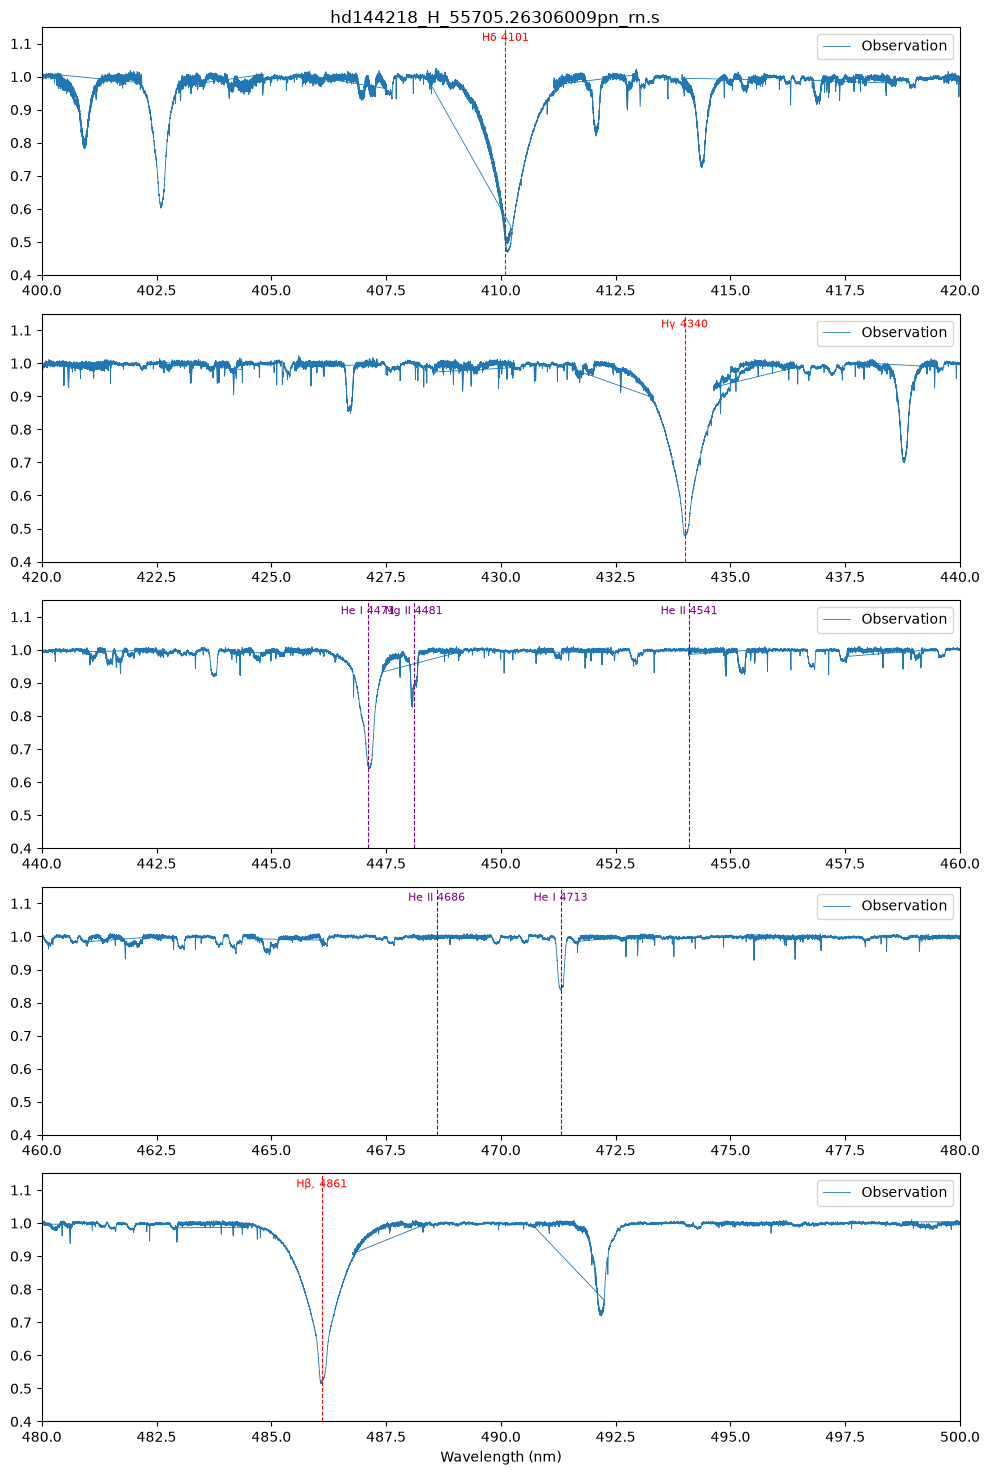

In [41]:

windows = [
    (400, 420),
    (420, 440),
    (440, 460),
    (460, 480),
    (480, 500)
]

lines = [
    (410.1, 'Hδ 4101'),
    (434.0, "Hγ 4340"),
        (486.1, "Hβ, 4861")]
lines_2 = [
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
]
vrad = 50
vsini = 20

fig, ax = plt.subplots(len(windows), 1, figsize=(10, 3 * len(windows)))
for i, (xmin, xmax) in enumerate(windows):
    ax[i].plot(spec.wl, spec.specI, lw=0.6, label="Observation")
    # ax[i].plot(joint.wl/10, joint.specI,
            #    lw=0.8, label=synthetic_spec_1+'\n'+synthetic_spec_2)
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.15)
    for wl, label in lines:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='red',ls='--',lw=0.8)
            ax[i].text(wl,1.1,label,color='red', ha='center',va='bottom',fontsize=8)
    for wl, label in lines_2:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='purple',ls='--',lw=0.8)
            ax[i].text(wl,1.1,label,color='purple', ha='center',va='bottom',fontsize=8)
    ax[i].legend()
ax[-1].set_xlabel("Wavelength (nm)")
fig.suptitle(f"{name}")
# fig.suptitle(f"{synthetic_spec_1}: vrad = {vrad1}, vsini = {vsini1} {synthetic_spec_2}: vrad = {vrad2}, vsini = {vsini2},R2/R1 = {R2R1}")
plt.tight_layout()
plt.show()


In [45]:
# Teff — match the He I/He II ionization balance (e.g., 4200, 4471, 4541).
# log g — Balmer wings (Hδ, Hγ, Hβ). higher log g, broader wings
# vsini — match the widths of the helium and metal lines.

params = {
    "teff1": 17000, "logg1": 350, "vsini1": 150, "vrad1":20,


    "R2R1": 1.0,
    "vturb": 2
}
# ---------------- Load TLUSTY models ----------------
file_name_1 = f"G{params['teff1']}g{params['logg1']}v{params['vturb']}.vis"

my_model_name1 = vp.tlusty.galB_path_name.format(
    "vis",
    params["teff1"],
    params["logg1"],
    str(params["vturb"])
)



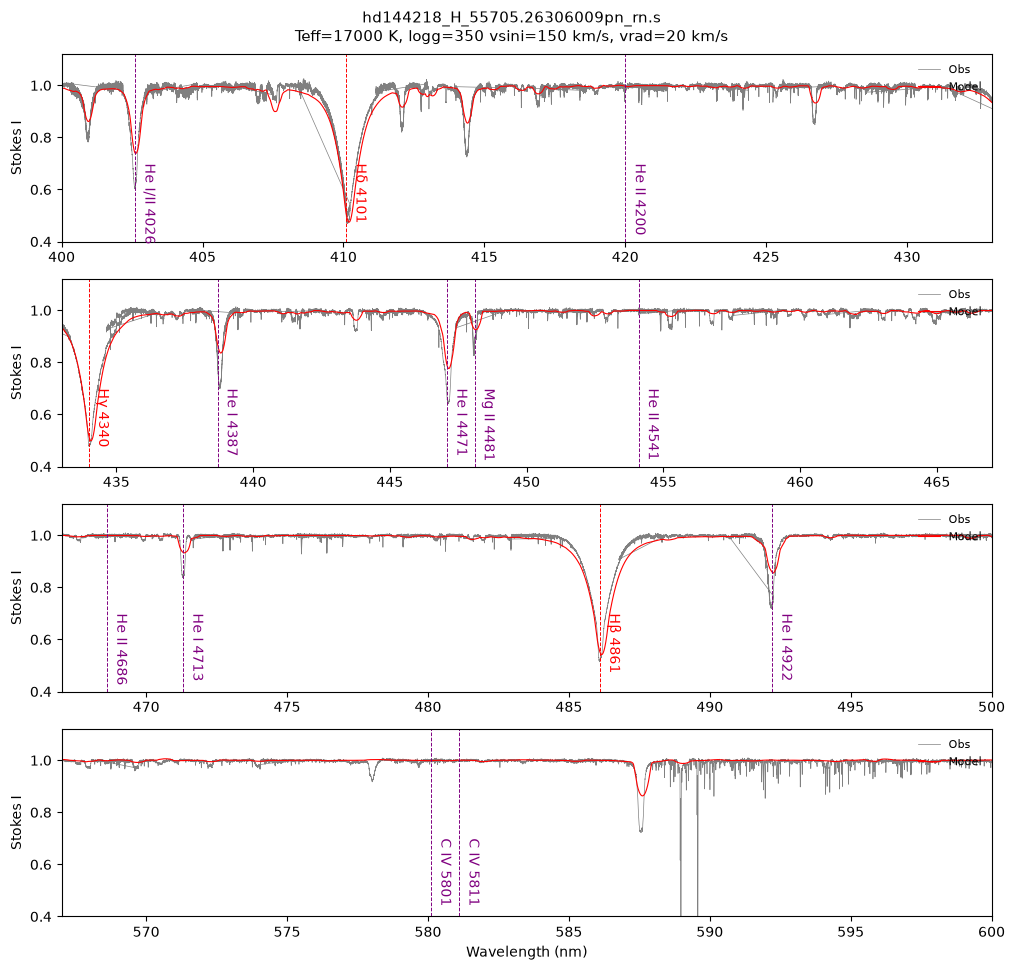

In [46]:
windows = [(400, 433), (433, 467), (467, 500), (567, 600)]

lines_H = [
    (410.1, "Hδ 4101"),
    (434.0, "Hγ 4340"),
    (486.1, "Hβ 4861"),
]

lines_He = [
    (402.6, "He I/II 4026"),
    (420.0, "He II 4200"),
    (438.7, "He I 4387"),
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
    (492.2, "He I 4922"),
    (501.6, "He I 5016"),
    (580.1, "C IV 5801"),
    (581.1, "C IV 5811"),
]


model = vp.tlusty.read_norm(path_google + my_model_name1)

# Apply radial velocity shift and rotational broadening
model = dopplershift_rotate(
    model,
    params["vrad1"],
    params["vsini1"]
)

# ---------------- Plot ----------------
fig, ax = plt.subplots(
    len(windows),
    1,
    figsize=(12, 2.8 * len(windows)),
    sharey=True
)

for i, (xmin, xmax) in enumerate(windows):

    ax[i].plot(spec.wl,spec.specI,color="grey",lw=0.5, label="Obs")

    ax[i].plot(model.wl / 10,model.specI, color="red",lw=0.8,label="Model")

    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.4, 1.12)
    ax[i].set_ylabel("Stokes I")

    # Put legend inside each panel
    ax[i].legend(loc="upper right",fontsize=8,frameon=False)

    # Hydrogen lines
    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl, color="red", ls="--", lw=0.7)
            ax[i].text(
                wl + 0.5,
                0.70,
                label,
                color="red",
                fontsize=10,
                rotation=-90,
                ha="center",
                va="top"
            )

    # Helium / metal lines
    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl, color="purple", ls="--", lw=0.7)
            ax[i].text(
                wl + 0.5,
                0.70,
                label,
                color="purple",
                fontsize=10,
                rotation=-90,
                ha="center",
                va="top"
            )

ax[-1].set_xlabel("Wavelength (nm)")

title = (f"{name}\n"
    f"Teff={params['teff1']} K, logg={params['logg1']} vsini={params['vsini1']} km/s, vrad={params['vrad1']} km/s\n"
)

fig.suptitle(title, fontsize=11, y=0.92)



plt.show()



In [ ]:
def make_binary_model(p): # B star
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galB_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label

In [ ]:
params_A = {
    "teff1": 17000, "logg1": 300,
    "teff2": 16000, "logg2": 300,
    "vsini1": 30, "vsini2": 30,
    "vrad1": -100, "vrad2": 100,
    "R2R1": 0.75,
    "vturb": 10,
}

params_B = {
    "teff1": 16000, "logg1": 300,
    "teff2": 16000, "logg2": 300,
    "vsini1": 30, "vsini2": 30,
    "vrad1": -100, "vrad2": 100,
    "R2R1": 0.75,
    "vturb": 10,
}

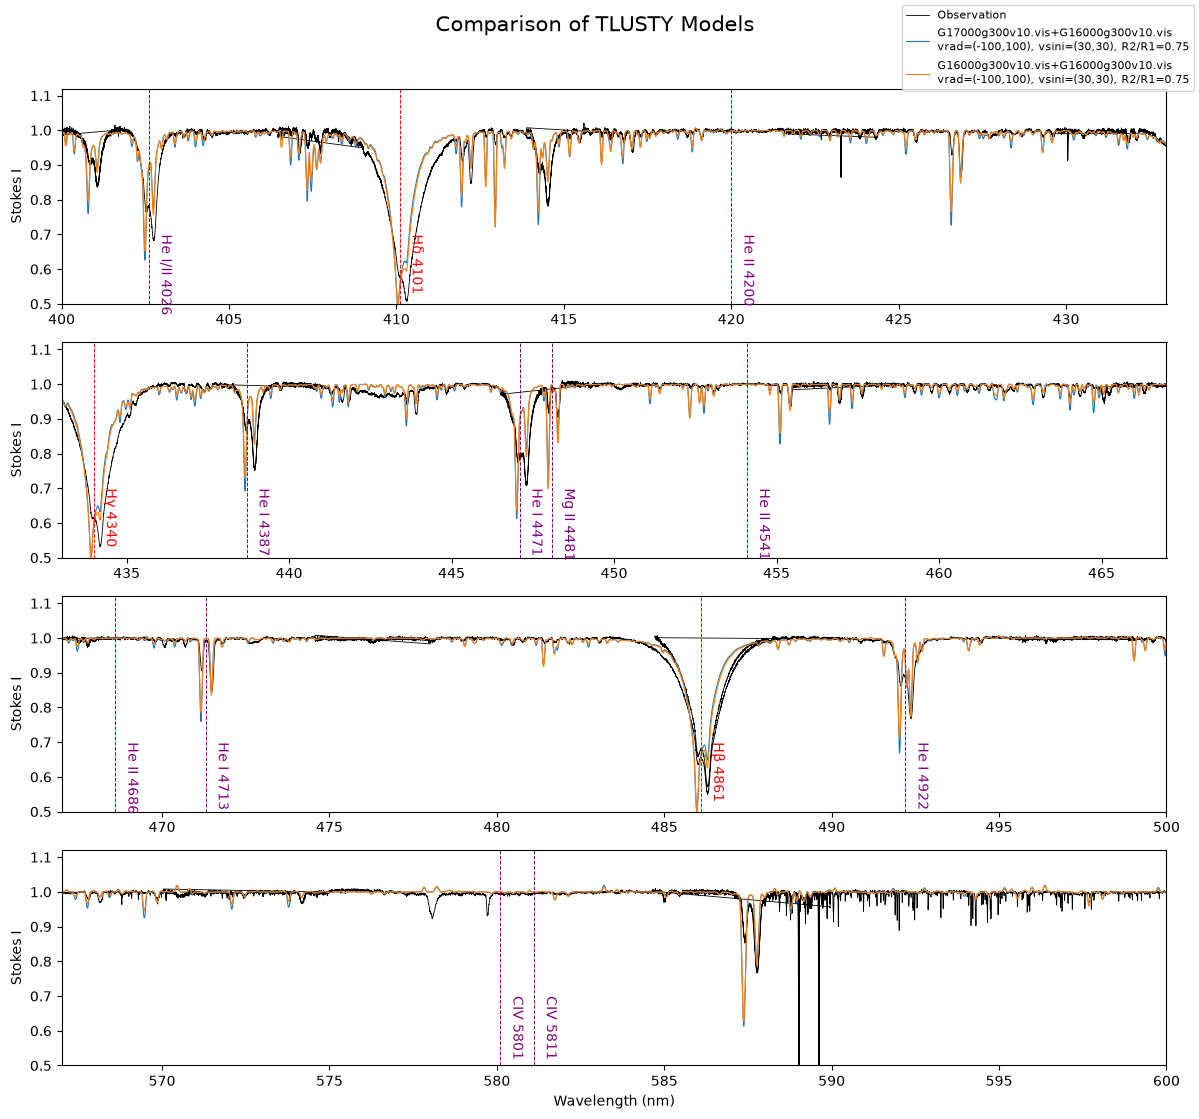

In [19]:
windows = [(400, 433),(433, 467),(467, 500),(567,600)]

lines_H = [(410.1, "Hδ 4101"),(434.0, "Hγ 4340"),(486.1, "Hβ 4861")]

lines_He = [(402.6, "He I/II 4026"),(420.0, "He II 4200"),(438.7, "He I 4387"),(447.1, "He I 4471"),
            (448.1, "Mg II 4481"),(454.1, "He II 4541"),(468.6, "He II 4686"),(471.3, "He I 4713"),(492.2, "He I 4922"),
            (501.6, "He I 5016"),(580.1,"CIV 5801"),(581.1,"CIV 5811")]



model_A, label_A = make_binary_model(params_A)
model_B, label_B = make_binary_model(params_B)

fig, ax = plt.subplots(len(windows), 1,figsize=(12, 2.8 * len(windows)))

for i, (xmin, xmax) in enumerate(windows):
    ax[i].plot(spec.wl, spec.specI, lw=0.6, color='k', label='Observation')
    ax[i].plot(model_A.wl/10, model_A.specI, lw=0.8, label=label_A)
    ax[i].plot(model_B.wl/10, model_B.specI, lw=0.8, label=label_B)
    ax[i].set_xlim(xmin, xmax)
    ax[i].set_ylim(0.5, 1.12)
    ax[i].set_ylabel("Stokes I")

    # Hydrogen lines
    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='red', ls='--',lw=0.7)

            ax[i].text(wl + 0.5,0.70,label,color='red',fontsize=10,rotation=-90,ha='center',va='top')
    # Helium / metal lines
    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            ax[i].axvline(wl,color='purple',ls='--',lw=0.7)
            ax[i].text(wl + 0.5,0.70,label,color='purple',fontsize=10,rotation=-90,ha='center',va='top')

ax[-1].set_xlabel("Wavelength (nm)")

# Only show legend once
handles, labels = ax[0].get_legend_handles_labels()


fig.legend(
    handles,
    labels,
    loc="upper right",
    fontsize=8
)

fig.suptitle("Comparison of TLUSTY Models",fontsize=15,y=0.99)

fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()